In [1]:
import numpy as np
import pandas as pn
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
data = pn.read_csv("adultcensusincome.csv")
data.shape

(32561, 14)

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   sex             32561 non-null  str  
 9   capital.gain    32561 non-null  int64
 10  capital.loss    32561 non-null  int64
 11  hours.per.week  32561 non-null  int64
 12  native.country  32561 non-null  str  
 13  income          32561 non-null  str  
dtypes: int64(6), str(8)
memory usage: 5.8 MB


In [15]:
data.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
income_encoded    0
dtype: int64

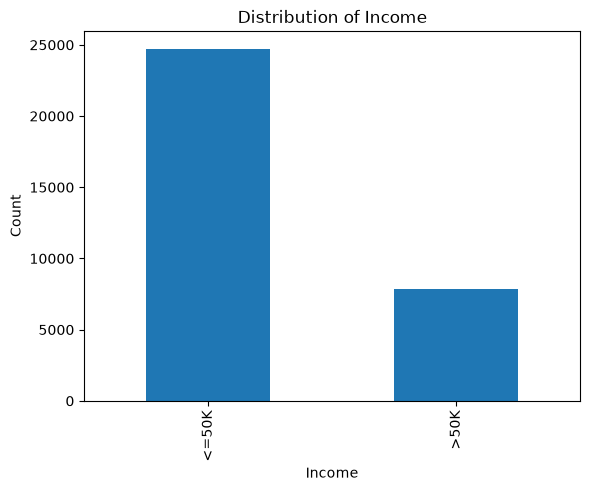

In [4]:
# Create a barplot for column income

data['income'].value_counts().plot(kind='bar')
plt.title('Distribution of Income')
plt.xlabel('Income')
plt.ylabel('Count')
plt.show()


# # Visual check
# data['income'].value_counts().plot(kind='bar')

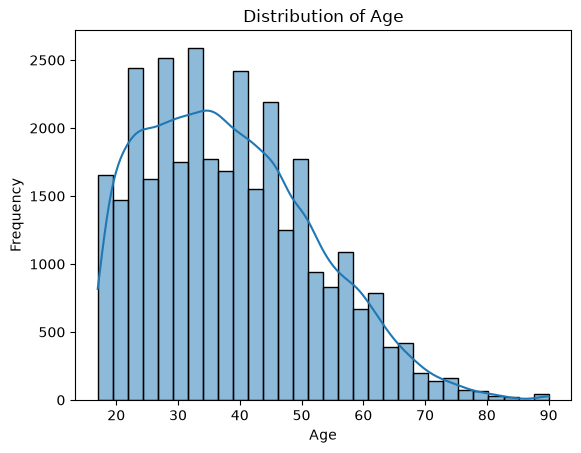

In [5]:
# Create a distribution plot for column age
sns.histplot(data['age'], kde=True, bins=30)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

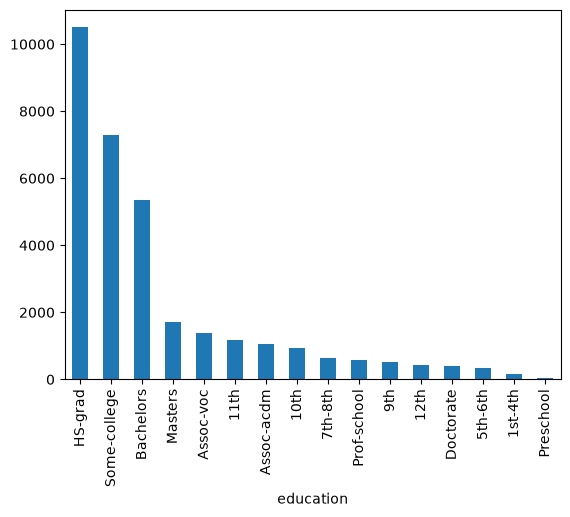

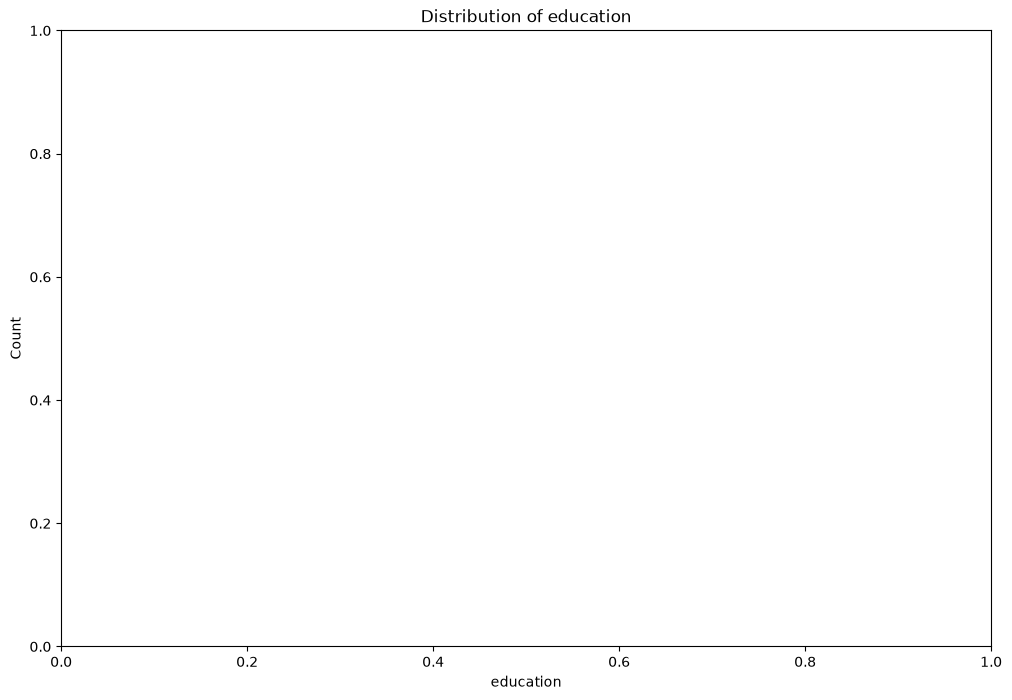

education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64

In [6]:
# Create a barplot for column education. 

data['education'].value_counts().plot(kind='bar')
plt.figure(figsize=(12, 8))
plt.title('Distribution of education')
plt.xlabel('education')
plt.ylabel('Count')
plt.show()
data['education'].value_counts()

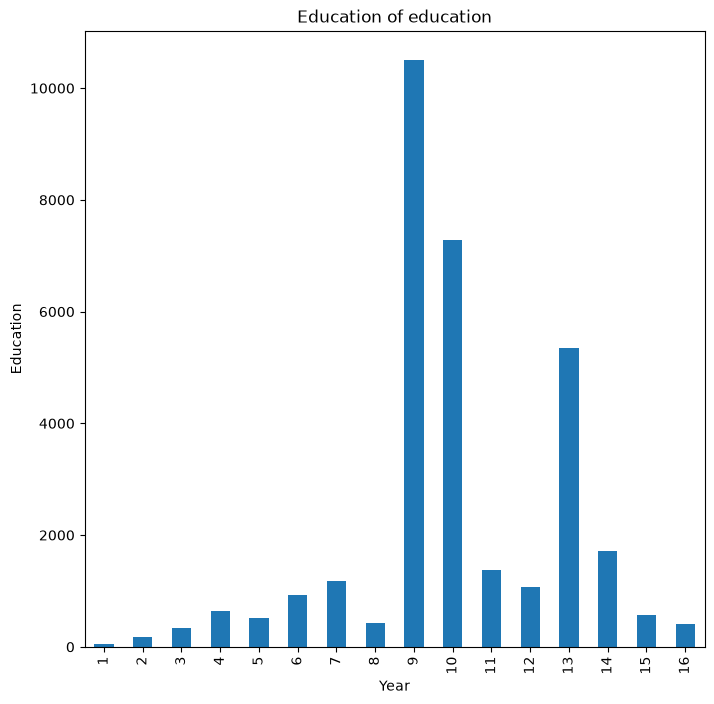

education.num
1        51
2       168
3       333
4       646
5       514
6       933
7      1175
8       433
9     10501
10     7291
11     1382
12     1067
13     5355
14     1723
15      576
16      413
Name: count, dtype: int64


In [7]:
# Create a barplot for Years of Education. Use column education.num
yearAdeucation = data['education.num'].value_counts().sort_index()
plt.figure(figsize=(8, 8))
yearAdeucation.plot(kind='bar')
plt.title('Education of education')
plt.xlabel('Year')
plt.ylabel('Education')
plt.show()
# data['education.num'].value_counts().sort_index()
 
print(yearAdeucation)

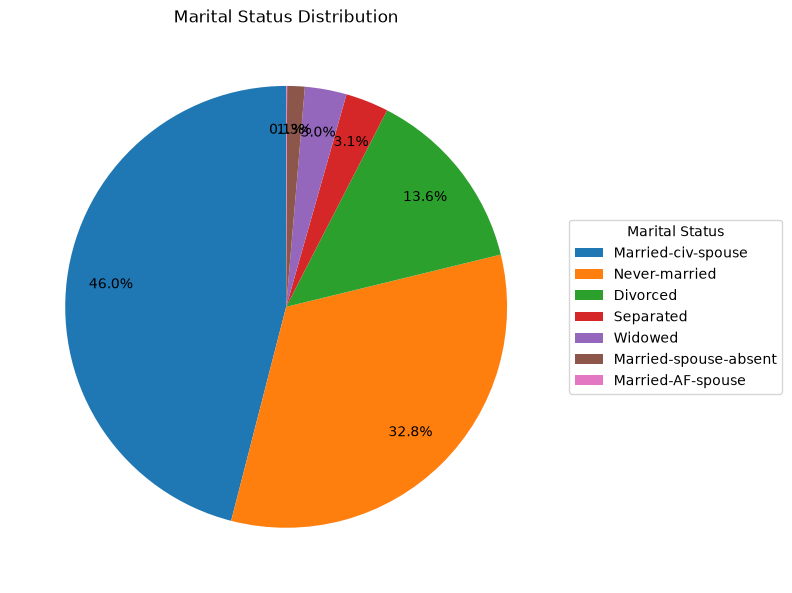

In [8]:
# Create a pie chart for Marital status. Use column marital.sta
counts = data['marital.status'].value_counts()

plt.figure(figsize=(8, 8))
counts.plot(
    kind='pie',
    autopct='%1.1f%%',      
    labels=None,            
    pctdistance=0.8,
    startangle=90
)
plt.title('Marital Status Distribution')
plt.ylabel('')
plt.legend(counts.index, title='Marital Status', loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

# Perform the following Bivariate analysis

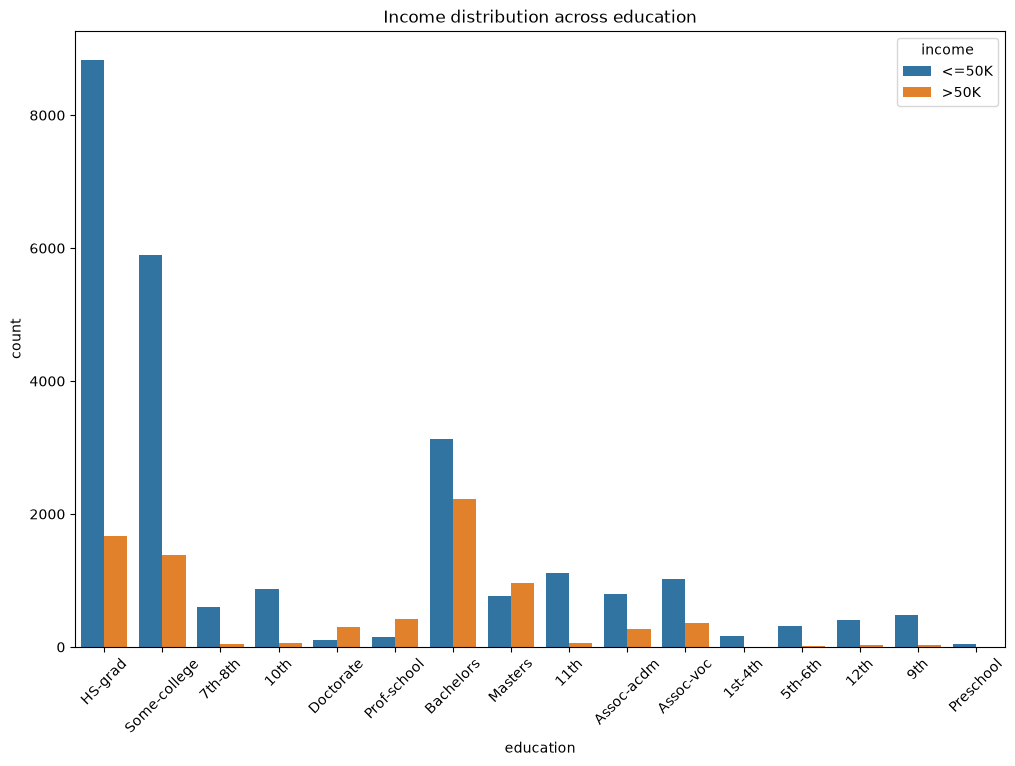

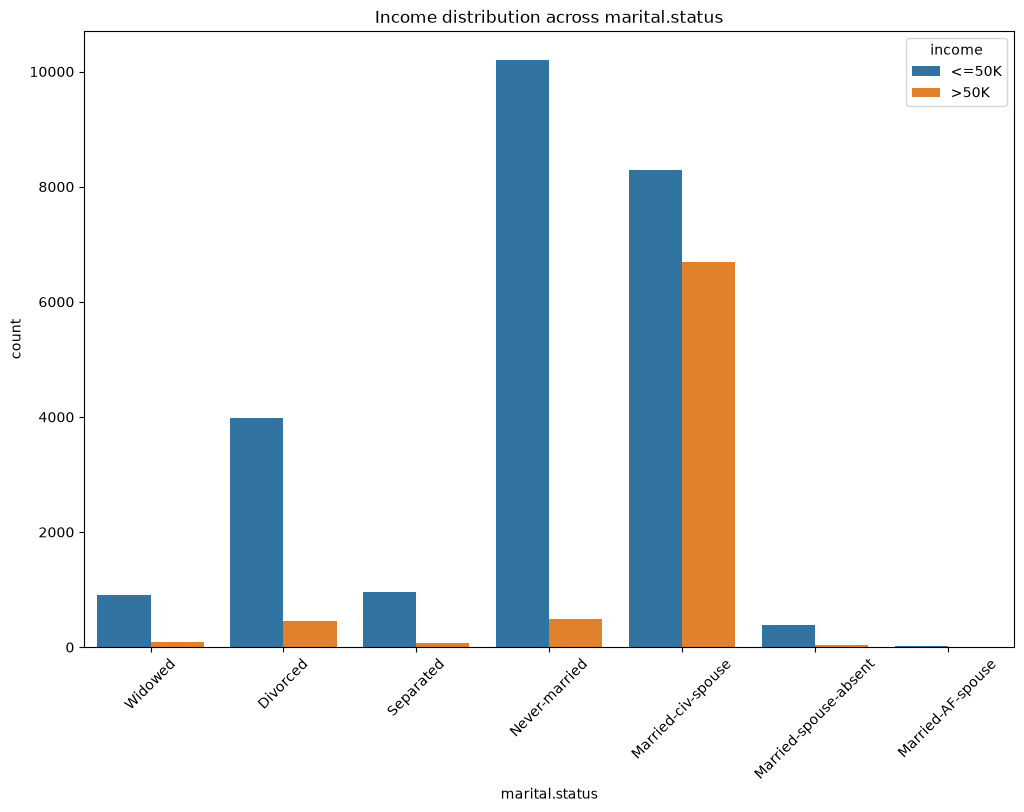

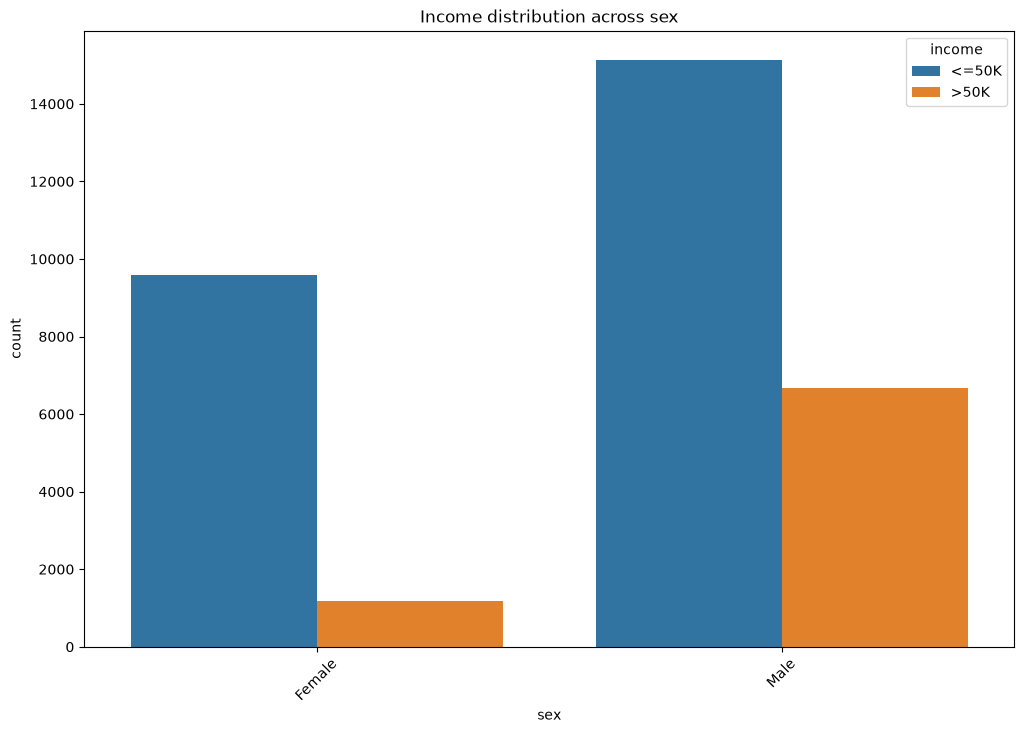

In [9]:
# Create a countplot of income across columns age, education, marital status, sex
for col in ['education', 'marital.status', 'sex']:
    plt.figure(figsize=(12, 8))
    sns.countplot(x=col, hue='income', data=data)
    plt.title(f'Income distribution across {col}')
    plt.xticks(rotation=45)
    plt.show()


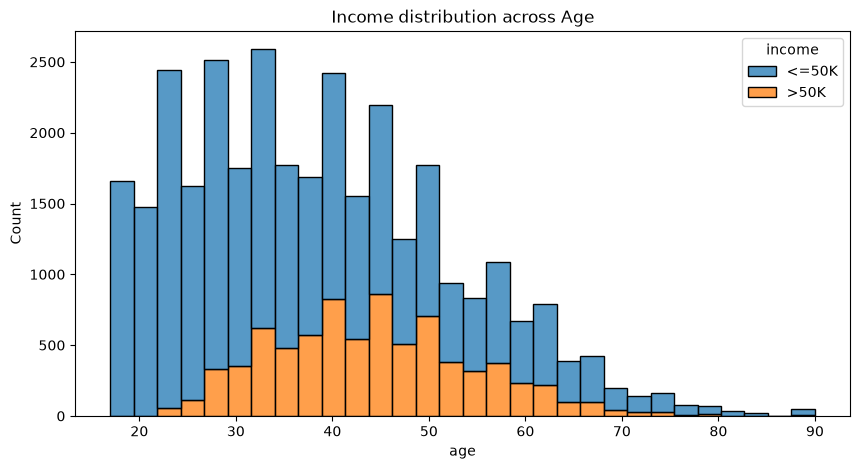

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(data=data, x='age', hue='income', multiple='stack', bins=30)
plt.title('Income distribution across Age')
plt.show()

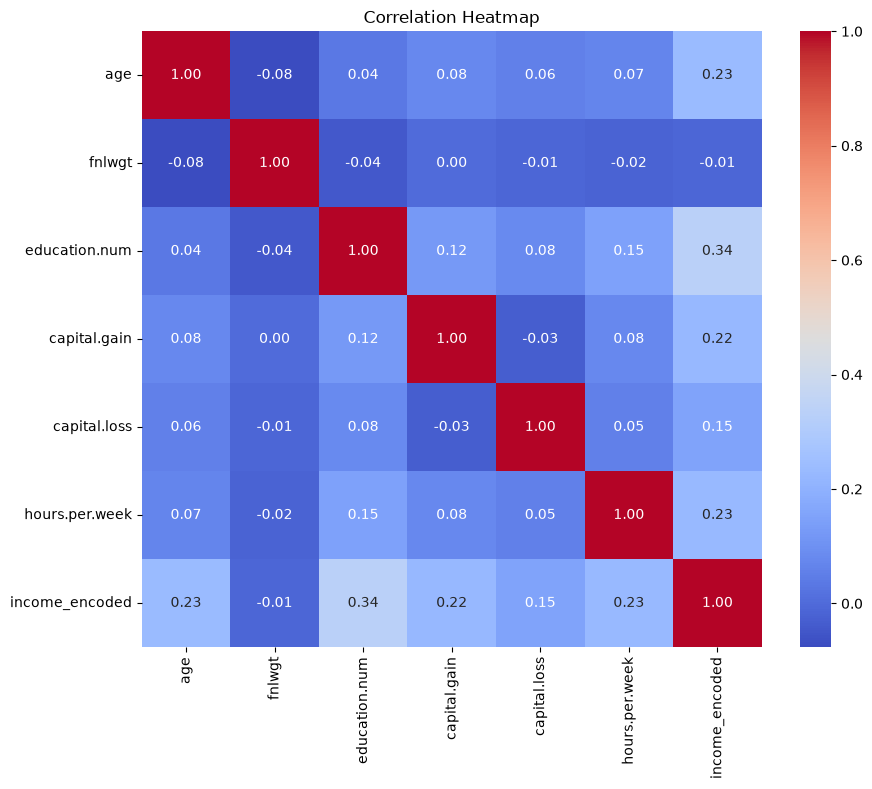

In [12]:
# Draw a heatmap of data correlation and find out the columns to which income is highly correlated

data['income_encoded'] = data['income'].map({'<=50K': 0, '>50K': 1})
corr = data.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [13]:
corr['income_encoded'].sort_values(ascending=False)

income_encoded    1.000000
education.num     0.335154
age               0.234037
hours.per.week    0.229689
capital.gain      0.223329
capital.loss      0.150526
fnlwgt           -0.009463
Name: income_encoded, dtype: float64

# Prepare the dataset for modeling

In [14]:
# Label encode all the categorical columns
categorical_cols = data.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"Column: {col}")
    print(f"Number of unique values: {data[col].nunique()}")
    print(data[col].unique())
    print("-" * 50)

Column: workclass
Number of unique values: 9
<ArrowStringArray>
[               '?',          'Private',        'State-gov',
      'Federal-gov', 'Self-emp-not-inc',     'Self-emp-inc',
        'Local-gov',      'Without-pay',     'Never-worked']
Length: 9, dtype: str
--------------------------------------------------
Column: education
Number of unique values: 16
<ArrowStringArray>
[     'HS-grad', 'Some-college',      '7th-8th',         '10th',
    'Doctorate',  'Prof-school',    'Bachelors',      'Masters',
         '11th',   'Assoc-acdm',    'Assoc-voc',      '1st-4th',
      '5th-6th',         '12th',          '9th',    'Preschool']
Length: 16, dtype: str
--------------------------------------------------
Column: marital.status
Number of unique values: 7
<ArrowStringArray>
[              'Widowed',              'Divorced',             'Separated',
         'Never-married',    'Married-civ-spouse', 'Married-spouse-absent',
     'Married-AF-spouse']
Length: 7, dtype: str
------------

/var/folders/f7/6ttbslv14mb1smgbhyrcq1xh0000gn/T/ipykernel_25452/4007184788.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data.select_dtypes(include='object').columns


In [16]:
(data == '?').sum()


age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
income_encoded       0
dtype: int64

In [18]:
# convert ? to Nan value 
data.replace('?', np.nan, inplace=True)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,sex,capital.gain,capital.loss,hours.per.week,native.country,income,income_encoded
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,Female,0,4356,40,United-States,<=50K,0
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,Female,0,4356,18,United-States,<=50K,0
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Female,0,4356,40,United-States,<=50K,0
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,Female,0,3900,40,United-States,<=50K,0
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,Female,0,3900,40,United-States,<=50K,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,Male,0,0,40,United-States,<=50K,0
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,Female,0,0,38,United-States,<=50K,0
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,Male,0,0,40,United-States,>50K,1
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,Female,0,0,40,United-States,<=50K,0


In [19]:
data.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
income_encoded       0
dtype: int64